# 05. Analytics - Pandas

## 05.1. Importação das bibliotecas

### 05.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys

### 05.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

### 05.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 05.2. Visão geral dos dados

### 05.2.1. Habilitando a exibição de todas as colunas e linhas

In [4]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 05.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 05.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(581983, 19)

### 05.2.4. Exibindo o dataset

In [7]:
df.head(5)

,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,price,extra_people,minimum_nights,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1,2,2,Real Bed,270.0,51.0,4,t,f,strict,2018,4
1,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1,1,2,Real Bed,161.0,45.0,4,f,f,strict,2018,4
2,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1,1,2,Real Bed,222.0,68.0,2,t,f,strict,2018,4
3,t,1.0,-22.988165,-43.193588,Apartment,Entire home/apt,3,1,1,2,Real Bed,308.0,86.0,2,f,f,strict,2018,4
4,t,1.0,-22.981269,-43.190457,Loft,Entire home/apt,2,1,1,2,Real Bed,219.0,80.0,3,t,f,strict,2018,4


### 05.2.5. Visualizando os detalhes do dataset

In [8]:
df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581983 entries, 0 to 581982
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   host_is_superhost         581983 non-null  object 
 1   host_listings_count       581983 non-null  float64
 2   latitude                  581983 non-null  float64
 3   longitude                 581983 non-null  float64
 4   property_type             581983 non-null  object 
 5   room_type                 581983 non-null  object 
 6   accommodates              581983 non-null  int64  
 7   bathrooms                 581983 non-null  int64  
 8   bedrooms                  581983 non-null  int64  
 9   beds                      581983 non-null  int64  
 10  bed_type                  581983 non-null  object 
 11  price                     581983 non-null  float64
 12  extra_people              581983 non-null  float64
 13  minimum_nights            581983 non-null  i

### 05.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,minimum_nights,ano,mes
count,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00,581983.00
mean,1.71,-22.96,-43.25,3.47,1.36,1.36,2.10,319.63,22.38,2.55,2018.85,6.34
std,1.22,0.04,0.10,1.63,0.58,0.73,1.23,262.00,33.89,1.64,0.72,3.40
min,0.00,-23.07,-43.72,1.00,0.00,0.00,0.00,0.00,0.00,1.00,2018.00,1.00
25%,1.00,-22.98,-43.30,2.00,1.00,1.00,1.00,138.00,0.00,1.00,2018.00,4.00
50%,1.00,-22.97,-43.20,3.00,1.00,1.00,2.00,228.00,0.00,2.00,2019.00,6.00
75%,2.00,-22.94,-43.19,4.00,2.00,2.00,3.00,401.00,50.00,3.00,2019.00,9.00
max,6.00,-22.75,-43.10,9.00,3.00,3.00,6.00,1276.00,125.00,8.00,2020.00,12.00


### 05.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,host_is_superhost,property_type,room_type,bed_type,instant_bookable,is_business_travel_ready,cancellation_policy
count,581983,581983,581983,581983,581983,581983,581983
unique,2,12,4,2,2,1,4
top,f,Apartment,Entire home/apt,Real Bed,f,f,flexible
freq,519412,458354,372443,570643,352395,581983,258096


### 05.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
price                       0
extra_people                0
minimum_nights              0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64

### 05.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

host_is_superhost               2
host_listings_count             7
latitude                    47567
longitude                   50975
property_type                  12
room_type                       4
accommodates                    9
bathrooms                       4
bedrooms                        4
beds                            7
bed_type                        2
price                        1248
extra_people                  115
minimum_nights                  8
instant_bookable                2
is_business_travel_ready        1
cancellation_policy             4
ano                             3
mes                            12
dtype: int64

### 05.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

26

### 05.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 12
- Categoric Columns: 7
- Date Columns: 0


## 05.3. Consolidação dos dados

### 05.3.1. Agrupando colunas e salvando em csv na camada gold para análise

- Agrupamento da coluna: host_is_superhost


host_is_superhost,Percentage,Count
f,89.2,519412
t,10.8,62571


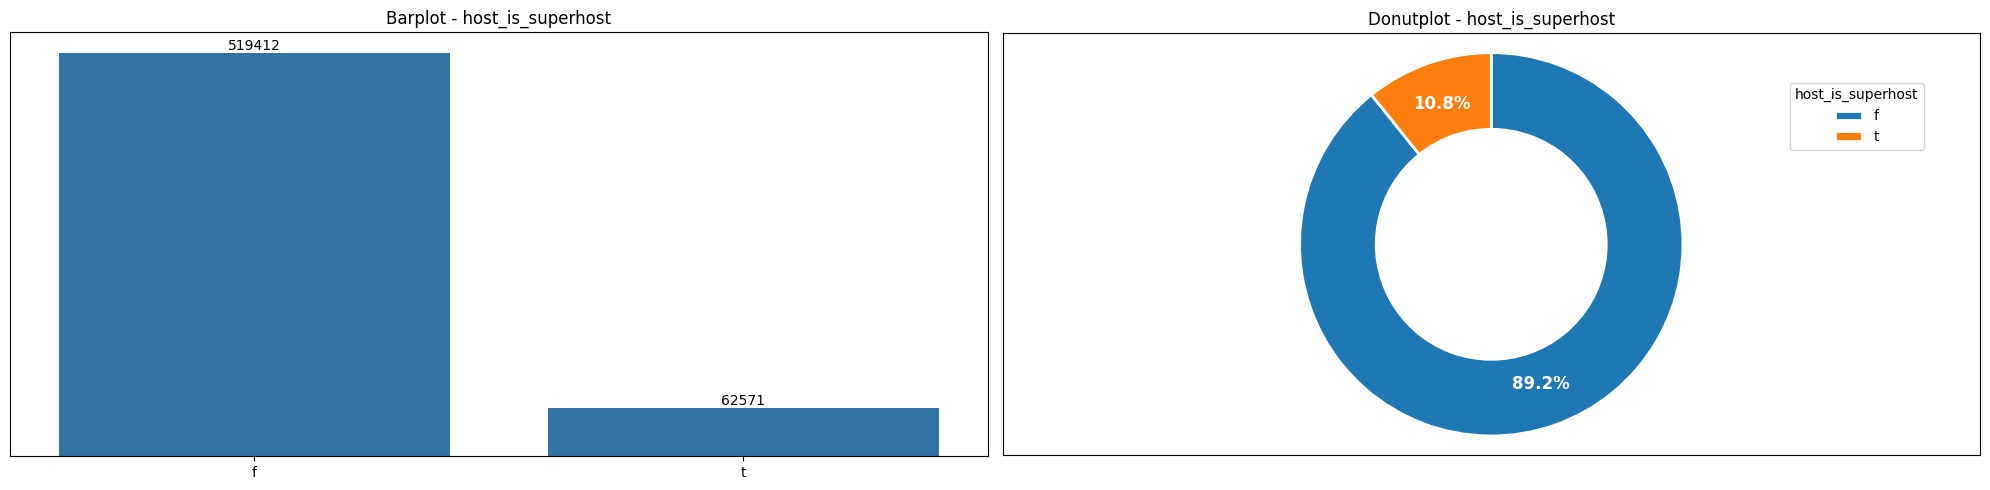

- Agrupamento da coluna: property_type


property_type,Percentage,Count
Apartment,78.8,458354
Bed and breakfast,0.6,3472
Condominium,4.5,26456
Guest suite,0.6,3621
Guesthouse,0.4,2155
Hostel,0.5,2665
House,8.8,51387
Loft,2.1,12352
Other,0.3,1957
Others,1.0,5599


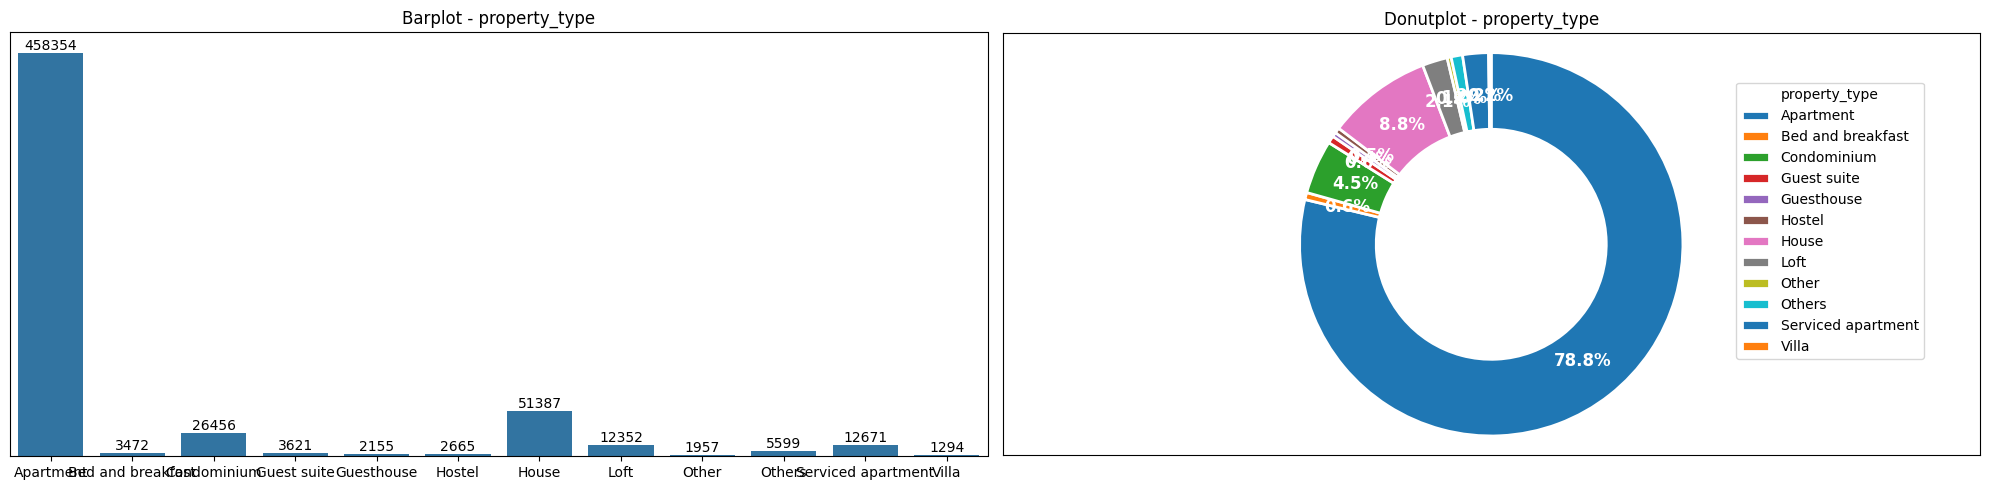

- Agrupamento da coluna: room_type


room_type,Percentage,Count
Entire home/apt,64.0,372443
Hotel room,0.2,967
Private room,33.8,196859
Shared room,2.0,11714


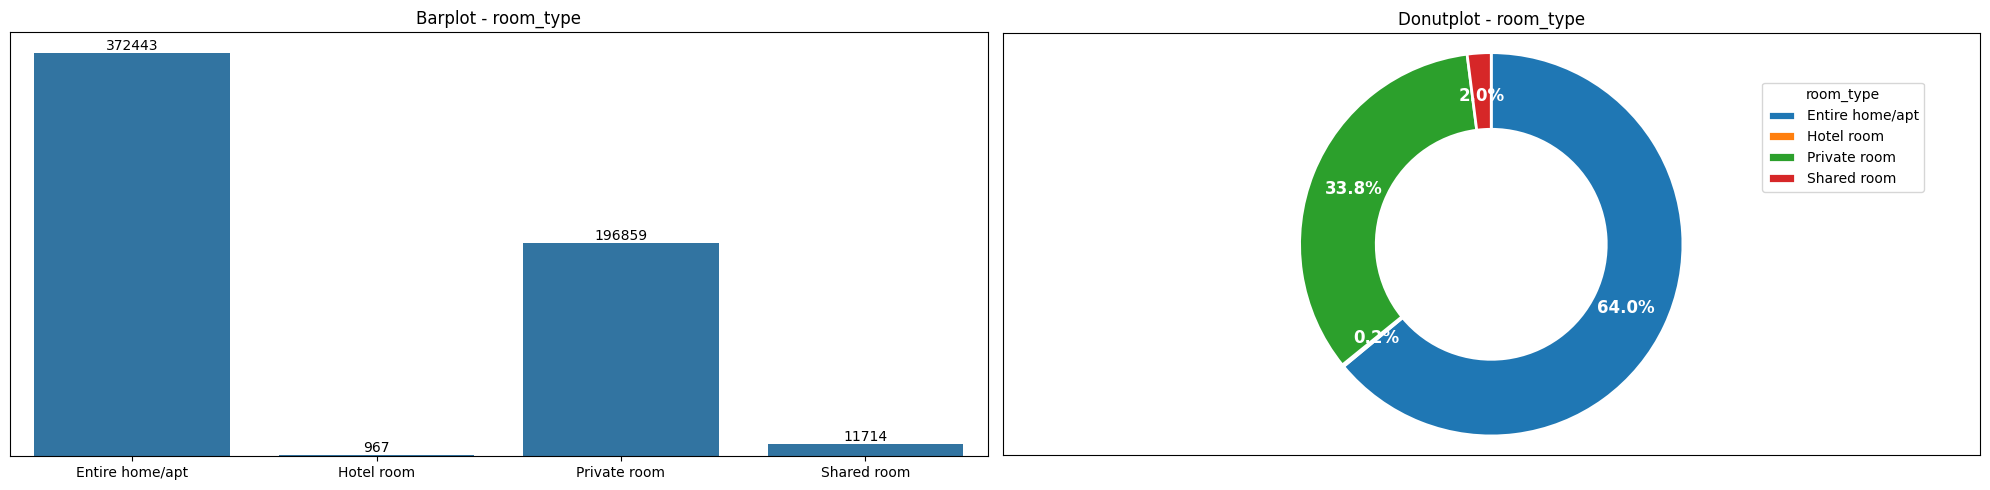

- Agrupamento da coluna: accommodates


accommodates,Percentage,Count
1,6.7,38850
2,31.7,184631
3,11.6,67662
4,27.5,159945
5,8.1,46875
6,11.3,65730
7,1.4,7981
8,1.6,9285
9,0.2,1024


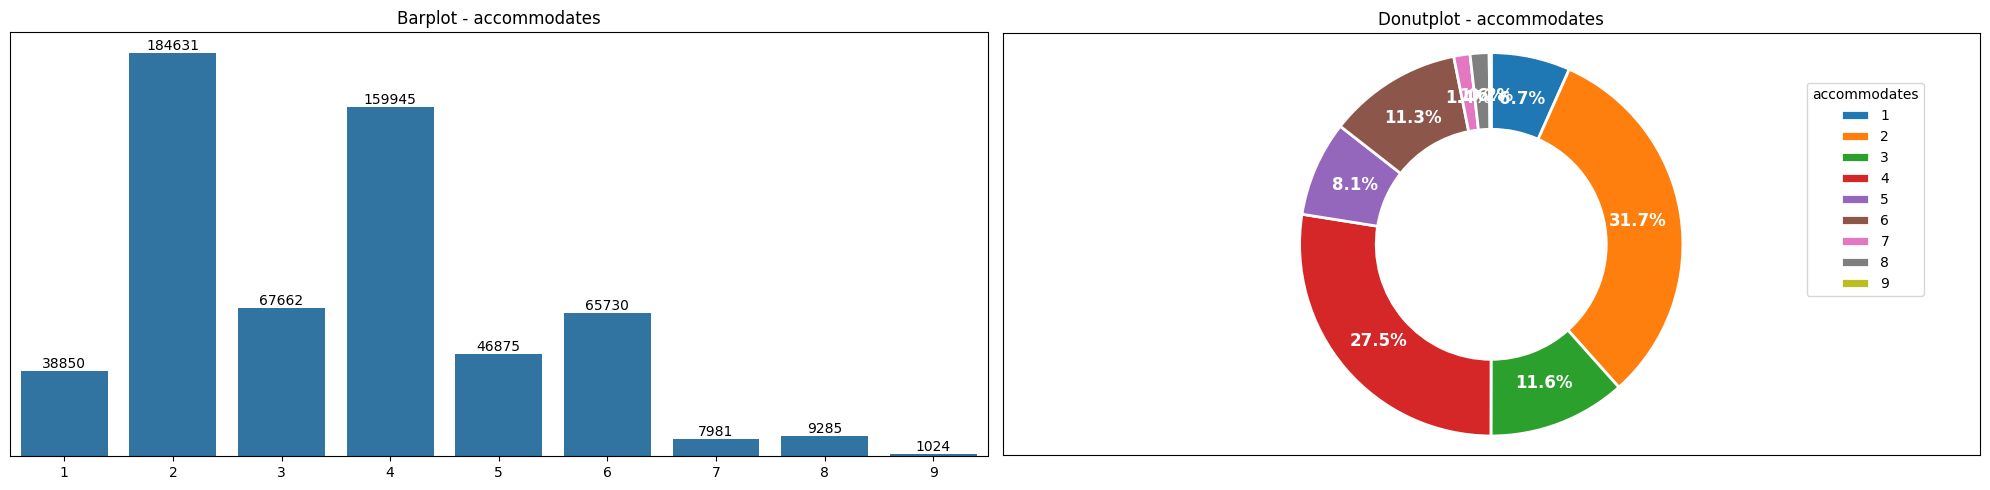

- Agrupamento da coluna: bathrooms


bathrooms,Percentage,Count
0,0.3,1920
1,68.0,395962
2,26.5,154021
3,5.2,30080


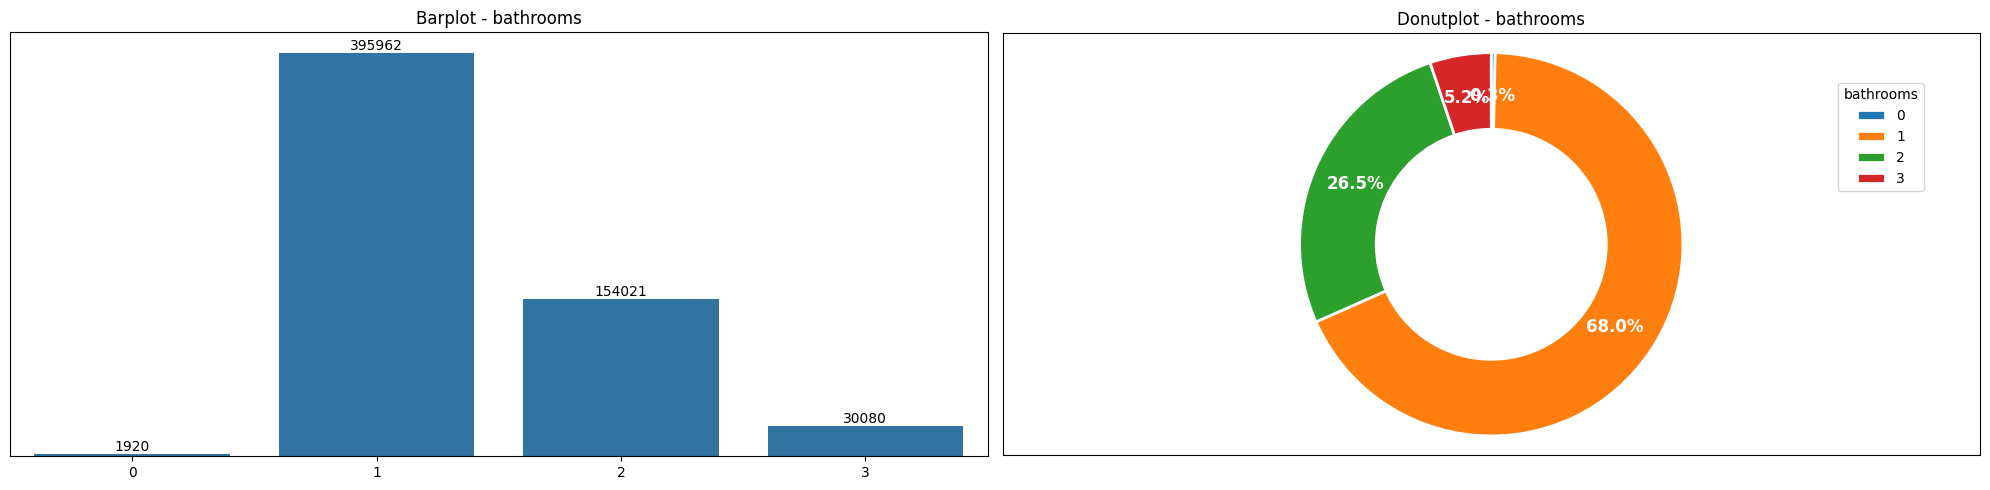

- Agrupamento da coluna: bedrooms


bedrooms,Percentage,Count
0,6.6,38485
1,59.3,344844
2,25.6,149204
3,8.5,49450


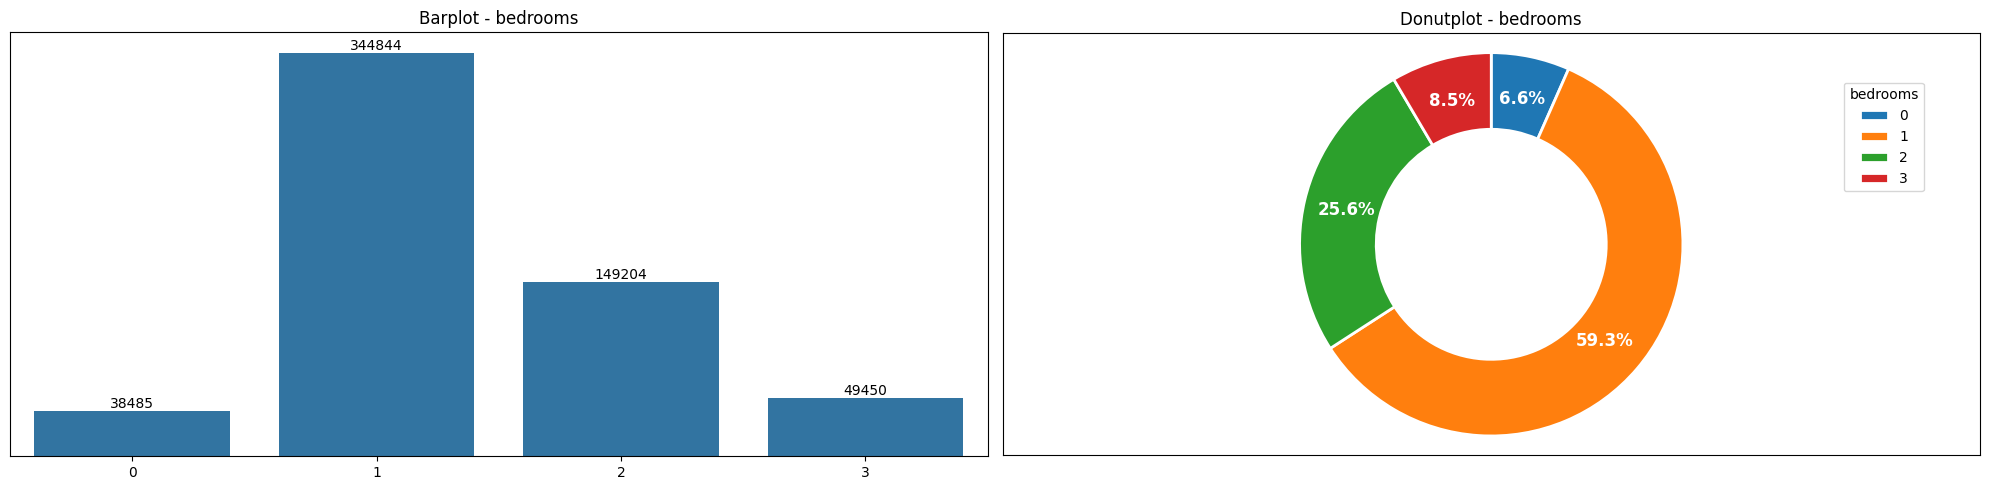

- Agrupamento da coluna: beds


beds,Percentage,Count
0,0.6,3427
1,39.4,229174
2,29.9,173980
3,16.5,96041
4,8.4,48927
5,3.4,19502
6,1.9,10932


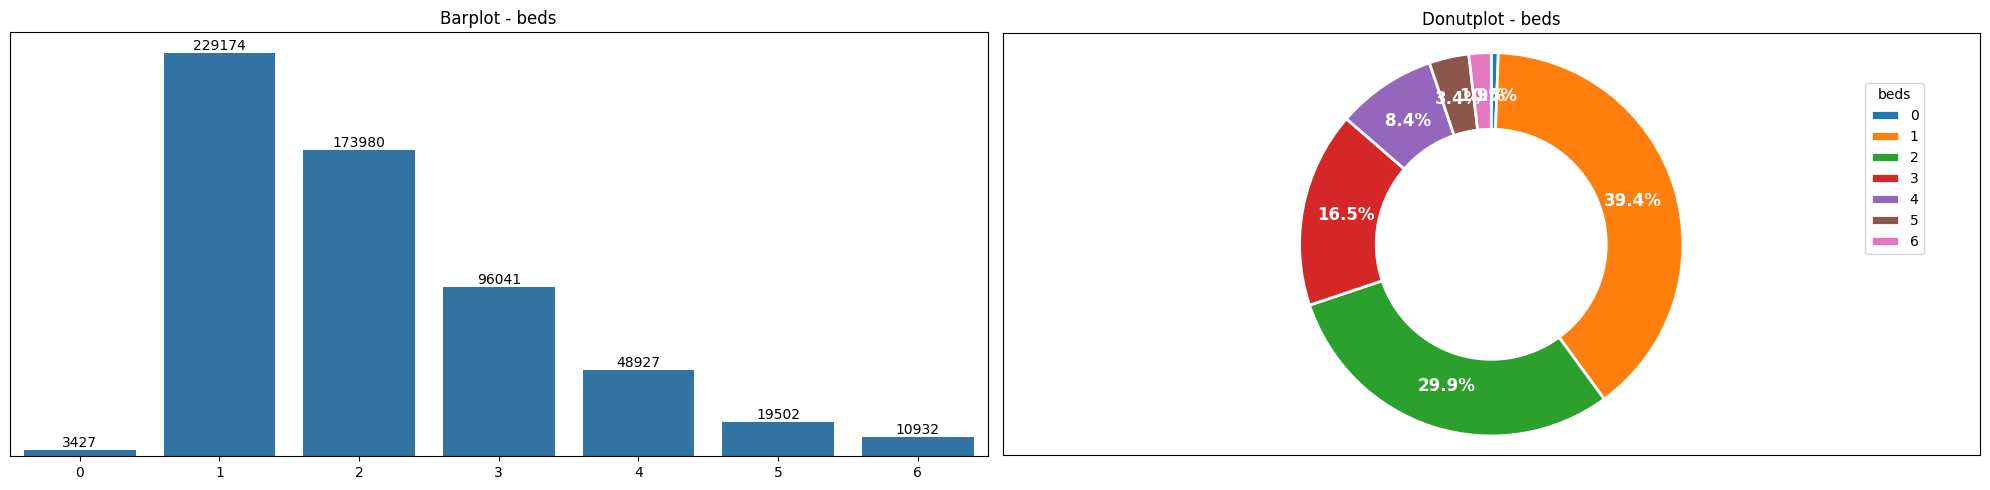

In [15]:
columns = ['host_is_superhost', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds']

for i in columns:

    df_agg = fn_stats_pandas.groupby_count(df, i)

    print(f'- Agrupamento da coluna: {i}')

    display(HTML(df_agg.to_html(index = False)))

    df_agg.to_csv(f'../data/04_gold/agg_{i.lower()}_pandas.csv', index = False)

    fn_charts_pandas.barplot_donutplot(df_agg, i, 'Count')

    plt.savefig(f'../images/outputs/charts/pandas/nb05_barplot_donutplot_{i.lower()}.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

    plt.show()